In [1]:
# from src.definitions.riclpm_funcs import read_res_riclpm
import pandas as pd 
import numpy as np
import pyreadr

import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

import warnings

In [2]:
RI_CLPM_results = './results_RI-CLPM'
ALT_SR_results  = './results_ALT-SR'

In [3]:
def read_results(depname, cmrname, stationary=False, strata=False, path = RI_CLPM_results):
    """Input: names of the depression report (sDEP = self or mDEP = parental reports) and cardio-metabolic risk (CMR)
       marker, + stationarity assumptions (whether CL and AR terms are contrained over time) and multigroup analyses
       Open the .RData file created by Rscript 1.RICLPM (one for dep-cmr marker pair) or 1.ALTRS 
       This contains the following elements:
       - fit_measures
       - estimates_un and standardized: unstandardized and standardized estimates (+ robust SE, pvalues and CIs)
       - correrations, data_summary, times: information about the dataset
    """
    if stationary:
        sub = '_pstat'  
    elif strata:
        sub = '_by_sex'
    else:
        sub = ''
    
    res = pyreadr.read_r(f'{path}/{depname}_{cmrname}{sub}.RData')

    fitm = res['fit_measures'].T.reset_index()

    esti = res['estimates_un']

    # Make covariance easier to query
    esti['label'].replace({'rcov': 'cor'}, regex=True, inplace=True)

    # Add standardized estimates
    esti[['u_est', 'u_ci.lower', 'u_ci.upper', 'u_pvalue']] = esti[['est', 'ci.lower', 'ci.upper', 'pvalue']]
    esti[['est', 'ci.lower', 'ci.upper', 'pvalue']] = res['standardized']

    esti['sign'] = [0 if p > 0.05 else 1 for p in esti['pvalue']]

    cors = res['correrations']
    summ = res['data_summary']

    # time = res['times']

    return fitm, esti, summ, cors


<ins>Revision 1</ins>: Compare the fit of RI-CLPM and ALT-SR models

In [ ]:
# pd.set_option('display.max_columns', None) 
from scipy.stats import chi2

def compare_fitm(dep_var, cmr_var):
    """Compare fit measures of the RI-CLPM and ALT-SR models"""
    try: 
        fitm_a, _, _, _ = read_results(dep_var, cmr_var, path=ALT_SR_results)
    except:
        return('ALT-SR model failed')
    
    fitm_r, _, _, _ = read_results(dep_var, cmr_var, path=RI_CLPM_results)
    
    fitm_comp = pd.concat([fitm_r, fitm_a])
    
    fitm_comp['index'] = ['RI-CLPM', 'ALT-SR']

    fitm_comp_out = round(fitm_comp[['index','npar','chisq','df','pvalue',
                                     'cfi', 'tli', 'rmsea', 'rmsea.ci.lower', 'rmsea.ci.upper','srmr',
                                     'aic', 'bic']], 3).reset_index(drop=True)
    
    delta_chi2 = fitm_comp_out.loc[0, 'chisq'] - fitm_comp_out.loc[1, 'chisq']  # RI-CLPM - ALT-SR
    delta_df = fitm_comp_out.loc[0, 'df'] - fitm_comp_out.loc[1, 'df']          # RI-CLPM - ALT-SR

    p_value = chi2.sf(delta_chi2, delta_df)

    print("Chi-square difference:", round(delta_chi2,3))
    print("Degrees of freedom difference:", round(delta_df,3))
    print("p-value:", round(p_value,3))
    print(" ")

    fitm_comp_out = fitm_comp_out.set_index('index').T

    def better_model(row):
        if row['RI-CLPM'] < row['ALT-SR']:  # For measures where lower is better
            return 'RI-CLPM'
        elif row['RI-CLPM'] > row['ALT-SR']:  # For measures where higher is better
            return 'ALT-SR'
        else:
            return 'Tie'

    # Define which measures should be maximized (higher is better)
    maximize_measures = ['cfi', 'tli', 'pvalue']
    
    # Apply the better model logic
    fitm_comp_out['Better Model'] = fitm_comp_out.apply(
        lambda row: better_model(row) if row.name not in maximize_measures else 
        ('RI-CLPM' if row['RI-CLPM'] > row['ALT-SR'] else 
         'ALT-SR' if row['RI-CLPM'] < row['ALT-SR'] else 'Tie'),
        axis=1
    )

    return(fitm_comp_out)


for dep_var in ['sDEP', 'mDEP']:
    for cmr_var in ['FMI','LMI','BMI','android_fatmass','waist_circ','HDL_chol','LDL_chol','insulin','triglyc','CRP']:
        print(f'\nComparing {dep_var} and {cmr_var}')
        print(compare_fitm(dep_var, cmr_var))



Comparing sDEP and FMI
Chi-square difference: 181.036
Degrees of freedom difference: 7.0
p-value: 0.0
 
index             RI-CLPM     ALT-SR Better Model
rownames                                         
npar               53.000     60.000      RI-CLPM
chisq             356.775    175.739       ALT-SR
df                 37.000     30.000       ALT-SR
pvalue              0.000      0.000          Tie
cfi                 0.991      0.996       ALT-SR
tli                 0.983      0.991       ALT-SR
rmsea               0.033      0.025       ALT-SR
rmsea.ci.lower      0.030      0.021       ALT-SR
rmsea.ci.upper      0.036      0.028       ALT-SR
srmr                0.027      0.012       ALT-SR
aic            -59878.296 -60045.332       ALT-SR
bic            -59508.174 -59626.326       ALT-SR

Comparing sDEP and LMI
Chi-square difference: 491.712
Degrees of freedom difference: 7.0
p-value: 0.0
 
index             RI-CLPM     ALT-SR Better Model
rownames                                

In [4]:
dep_var = 'sDEP'
cmr_var = 'FMI'

# Model output
fitm, esti, summ, cors = read_results(dep_var, cmr_var)

# Times / number of observations
td = [float(i.split('_')[-1][:-1]) for i in summ.columns[summ.columns.str.contains(dep_var)]]
tf = [float(i.split('_')[-1][:-1]) for i in summ.columns[summ.columns.str.contains(cmr_var)]]
n_obs = len(td)

# Data 
data = pd.read_csv('../mats/raw_data.csv')

dset = data.loc[(data[summ.columns[summ.columns.str.contains(dep_var)]].T.isna().sum() < len(td)) &
                (data[summ.columns[summ.columns.str.contains(cmr_var)]].T.isna().sum() < len(tf)), ]

print(data.shape, dset.shape, fitm.ntotal)

(15645, 386) (7970, 386) 0    7970.0
Name: ntotal, dtype: float64


In [8]:
data = pd.read_csv('../mats/raw_data_AFAR.csv')
dset = data.loc[(data[summ.columns[summ.columns.str.contains(dep_var)]].T.isna().sum() < len(td)) &
                (data[summ.columns[summ.columns.str.contains(cmr_var)]].T.isna().sum() < len(tf)), ]


# Descriptives 

In [9]:
t1vars = dset.loc[:, list(summ.columns[:n_obs*2])+['sex', 'ethnicity','m_edu', 'p_edu']]

In [10]:
def summ1(v, dec=0):
    return(f'{v.median():.{dec}f} ({v.min():.{dec}f}-{v.max():.{dec}f}) [{(v.isna().sum()/v.shape[0]*100):.0f}%]')
    
for vname in t1vars.iloc[:,:n_obs*2]:
    
    v = t1vars[vname]
    v1 = t1vars.loc[t1vars.sex=='Male', vname]
    v2 = t1vars.loc[t1vars.sex=='Female', vname]

    dec = 0 if vname.__contains__('DEP') else 1
    s, s1, s2 = summ1(v, dec), summ1(v1, dec), summ1(v2, dec)

    print(s, s1, s2, sep='\t')

print(v.shape[0], v1.shape[0], v2.shape[0])

3 (0-23) [16%]	3 (0-23) [14%]	3 (0-21) [17%]
3 (0-25) [20%]	3 (0-25) [19%]	3 (0-24) [22%]
4 (0-26) [27%]	3 (0-26) [25%]	4 (0-26) [29%]
4 (0-26) [44%]	3 (0-26) [53%]	5 (0-26) [37%]
5 (0-26) [47%]	4 (0-26) [53%]	6 (0-26) [42%]
5 (0-26) [55%]	4 (0-26) [67%]	5 (0-26) [43%]
3.8 (0.7-25.3) [52%]	3.0 (0.7-15.4) [51%]	4.4 (1.0-25.3) [52%]
4.4 (0.9-19.1) [17%]	3.7 (0.9-16.9) [16%]	4.9 (1.1-19.1) [19%]
4.6 (0.8-21.9) [27%]	3.1 (0.8-17.7) [26%]	5.7 (1.5-21.9) [29%]
5.0 (0.7-22.8) [39%]	2.8 (0.7-20.0) [39%]	6.4 (1.5-22.8) [38%]
5.8 (0.5-27.9) [42%]	3.4 (0.5-24.1) [47%]	7.1 (0.5-27.9) [38%]
7.2 (0.6-28.5) [55%]	5.7 (1.8-23.2) [65%]	8.0 (0.6-28.5) [46%]
8279 3955 4324


In [11]:
def summ2(vname, countna=False):
    
    vt = t1vars[vname]
    v1 = t1vars.loc[t1vars.sex=='Male', vname]
    v2 = t1vars.loc[t1vars.sex=='Female', vname]

    for v in [vt, v1, v2]:
        order = sorted(list(vt.dropna().unique()))+[np.nan] if vname!='sex' else v.unique()
        
        counts = v.value_counts(dropna=False)[order]
        percs = v.value_counts(dropna=False, normalize=True)[order].mul(100).round(0)
        
        if not countna: 
            percs.iloc[0:3,] = v.value_counts(dropna=True, normalize=True)[order[:-1]].mul(100).round(0)

        df = pd.concat([counts, percs],axis=1)

        df['print'] = [f'{c} ({p:.0f}%)' for c,p in zip(counts, percs)] # ], axis=1, keys=['count', 'percentage']).to_string(index=False))

        print(df.index)
        print(df['print'].to_string(index=False))

# summ2('sex')
# summ2('ethnicity')
# summ2('m_edu')
# summ2('p_edu')

## Results

In [7]:
print(f'({fitm.df[0]:.0f}) = {fitm.chisq[0]:.2f}, p={fitm.pvalue[0]:.3f}; \
RMSEA [95%CI] = {fitm.rmsea[0]:.3f} [{fitm.loc[0,"rmsea.ci.lower"]:.3f}-{fitm.loc[0,"rmsea.ci.upper"]:.3f}]; \
CFI = {fitm.cfi[0]:.3f}; TLI = {fitm.tli[0]:.3f}; SRMR = {fitm.srmr[0]:.3f}')

(37) = 356.77, p=0.000; RMSEA [95%CI] = 0.033 [0.030-0.036]; CFI = 0.991; TLI = 0.983; SRMR = 0.027


In [8]:
print(esti.loc[esti.label.str.contains('CL_dep'), ['est','se']].mean().round(3))

esti.loc[esti.label.str.contains('CL_dep')].round(3)

est    0.071
se     0.030
dtype: float64


,lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,u_est,u_ci.lower,u_ci.upper,u_pvalue,sign
25,w_dep2,~,w_cmr1,CL_dep1,0.043,0.027,2.017,0.044,0.001,0.085,0.055,0.002,0.108,0.044,1
29,w_dep3,~,w_cmr2,CL_dep2,0.025,0.024,1.345,0.179,-0.012,0.062,0.032,-0.015,0.078,0.179,0
33,w_dep4,~,w_cmr3,CL_dep3,0.128,0.029,6.156,0.000,0.087,0.169,0.181,0.124,0.239,0.000,1
37,w_dep5,~,w_cmr4,CL_dep4,0.077,0.027,3.557,0.000,0.035,0.119,0.096,0.043,0.149,0.000,1
41,w_dep6,~,w_cmr5,CL_dep5,0.083,0.044,3.134,0.002,0.032,0.135,0.136,0.051,0.222,0.002,1


In [9]:
print(esti.loc[esti.label.str.contains('CL_cmr'), ['est','se']].mean().round(3))

esti.loc[esti.label.str.contains('CL_cmr')].round(3)

est    0.041
se     0.009
dtype: float64


,lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,u_est,u_ci.lower,u_ci.upper,u_pvalue,sign
27,w_cmr2,~,w_dep1,CL_cmr1,0.033,0.009,2.881,0.004,0.010,0.055,0.027,0.009,0.046,0.004,1
31,w_cmr3,~,w_dep2,CL_cmr2,0.038,0.011,3.129,0.002,0.014,0.062,0.034,0.013,0.055,0.002,1
35,w_cmr4,~,w_dep3,CL_cmr3,0.051,0.008,5.631,0.000,0.033,0.069,0.044,0.029,0.059,0.000,1
39,w_cmr5,~,w_dep4,CL_cmr4,0.026,0.008,2.148,0.032,0.002,0.050,0.016,0.001,0.031,0.032,1
43,w_cmr6,~,w_dep5,CL_cmr5,0.058,0.011,2.014,0.047,0.001,0.115,0.023,0.001,0.045,0.044,1


In [10]:
esti.loc[esti.rhs.str.contains('ri_')].round(3)

,lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,u_est,u_ci.lower,u_ci.upper,u_pvalue,sign
50,ri_dep,~~,ri_cmr,covRI,0.111,0.000,4.313,0.0,0.062,0.161,0.001,0.001,0.002,0.0,1
63,ri_dep,~~,ri_dep,,1.000,0.000,26.468,NaN,1.000,1.000,0.012,0.011,0.013,0.0,1
64,ri_cmr,~~,ri_cmr,,1.000,0.001,22.275,NaN,1.000,1.000,0.014,0.013,0.015,0.0,1


In [11]:
esti.loc[esti.label.str.contains('co')].round(3)

,lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,u_est,u_ci.lower,u_ci.upper,u_pvalue,sign
44,w_dep1,~~,w_cmr1,cor1,-0.082,0.0,-4.051,0.000,-0.121,-0.042,-0.002,-0.003,-0.001,0.000,1
45,w_dep2,~~,w_cmr2,cor2,0.018,0.0,0.838,0.402,-0.024,0.060,0.000,-0.000,0.001,0.402,0
46,w_dep3,~~,w_cmr3,cor3,0.100,0.0,6.086,0.000,0.068,0.131,0.002,0.001,0.002,0.000,1
47,w_dep4,~~,w_cmr4,cor4,0.108,0.0,5.856,0.000,0.072,0.144,0.002,0.001,0.002,0.000,1
48,w_dep5,~~,w_cmr5,cor5,-0.023,0.0,-1.215,0.223,-0.061,0.014,-0.000,-0.001,0.000,0.224,0
49,w_dep6,~~,w_cmr6,cor6,0.100,0.0,3.002,0.003,0.033,0.166,0.001,0.000,0.002,0.003,1
50,ri_dep,~~,ri_cmr,covRI,0.111,0.0,4.313,0.000,0.062,0.161,0.001,0.001,0.002,0.000,1


In [ ]:
pd.options.mode.chained_assignment = None # avoid SettingWithCopyWarning

def get_results(name, dep='sDEP', cmr='FMI', model ='riclpm'):

    if model == 'riclpm':
        _, esti, summ, _ = read_results(dep, cmr)
    else:
        _, esti, summ, _ = read_results(dep, cmr, path=ALT_SR_path)
        
    # Times / number of observations
    td = [float(i.split('_')[-1][:-1]) for i in summ.columns[summ.columns.str.contains(dep)]]
    tf = [float(i.split('_')[-1][:-1]) for i in summ.columns[summ.columns.str.contains(cmr)]]


    if name.__contains__('AR'):
        (t1, t2) = (td, td) if name.__contains__('dep') else (tf, tf)
    else:
        (t1, t2) = (tf, td) if name.__contains__('dep') else (td, tf)  # ONLY for CL terms

    if (name == 'cov') or (name == 'cor'):
        diff = abs(np.subtract(t2, t1))
        link = '--'
        times = zip(t1, t2)
    else:
        diff = np.subtract(t2[1:], t1[:-1])
        link = '⟶'
        times = zip(t1[:-1], t2[1:])
    # print(d)
    
    es = esti.loc[esti.label.str.contains(name)]

    es['est2'] = [f'{e:.2f} [{l:.2f}; {u:.2f}]' for e,l,u in zip((es['est']).round(2),
                                                                 (es['ci.lower']).round(2),
                                                                 (es['ci.upper']).round(2))]
    
    es['age'] = [f'{i} {link} {j}' for i,j in  times] if name != 'cov' else None
    es['time'] = diff.round(1) if name != 'cov' else 1
    # es['yest'] = [f'{e:.2f} [{l:.2f}; {u:.2f}]' for e,l,u in zip((es['est'] / diff).round(2),
    #                                                              (es['ci.lower'] / diff).round(2),
    #                                                              (es['ci.upper'] / diff).round(2))]
    es['P'] = es['pvalue'].round(3)
    
    out = es[['est2','age','time','P', 'est','ci.lower','ci.upper']] # 'yest',
    out.insert(0, 'term', es.label)
    out.insert(0, 'cmr', cmr)
    
    # print(cmr,name, ' - estim:', np.mean(es.est).round(3),' - se:',np.mean(es.se).round(3))
    
    return(out)

# out_list = []

# for term in ['AR_dep','AR_cmr','CL_dep','CL_cmr', 'cor']:
#     d = get_results(name=term, dep='sDEP', cmr='FMI')
#     out_list.append(d)
    
# # see pd.concat documentation for more info
# out_table = pd.concat(out_list)
# # write DataFrame to an excel sheet 
# out_table.to_csv('~/Desktop/table2.csv')

# out_list = []

# for cmr in ['LMI','BMI','android_fatmass','waist_circ','tot_chol','HDL_chol','LDL_chol','insulin','triglyc','CRP']:
#     for term in ['CL_dep','CL_cmr']:
#         d = get_results(name=term, dep='sDEP', cmr=cmr)
#         out_list.append(d)
    
# # see pd.concat documentation for more info
# out_table = pd.concat(out_list)
# # write DataFrame to an excel sheet 
# out_table.to_csv('~/Desktop/table3.csv')


# out_list = []

# for cmr in ['FMI','LMI','BMI','waist_circ']:
#     for term in ['CL_dep','CL_cmr']:
#         d = get_results(name=term, dep='mDEP', cmr=cmr)
#         out_list.append(d)
    
# # see pd.concat documentation for more info
# out_table = pd.concat(out_list)
# # write DataFrame to an excel sheet 
# out_table.to_csv('~/Desktop/table4.csv')


# Plots

General parameters

In [28]:
figwidth=20
fs_l=18
fs_m=15
fs_s=12
fs_xs=10

In [29]:
dep_colors = ('blue', 'orange')
cmr_colors = ('crimson', 'purple')

lighter_colors = {'blue': '#7F7FF7', 'orange': '#F8D38B', 'crimson': '#DF8E9D', 'purple': '#B682BB'}

cp_color = '#F2F4F4' # light grey

age_range = (9,26.1)

## FIGURE 1

In [16]:
# d = dset[summ.columns[summ.columns.str.contains('sDEP')]].melt()

# d['sqrt'] = d['value'].transform(np.sqrt)
# d = d.rename(columns=dict(variable='vname',value='og',sqrt='trans'))
# d = d.melt(id_vars=['vname'])

# d['time'] = [float(i.split('_')[-1][:-1]) for i in d['vname']]

# sns.violinplot(data=d, x='time', y='value', hue='variable', 
#                color=dep_colors[0], palette=[dep_colors[0]]*2, alpha=0.5, inner_kws=dict(alpha=0.5),
#                split=True, gap=.05, inner="quart", ax=axs['A'])


In [17]:
def age_dist(ax, var, ylimit=3): 

    times = td if var == dep_var else tf
    
    ages = dset.columns[dset.columns.str.contains(f'age')]

    age_name = var if var == dep_var else 'CMR'
    agevars = ages[ages.str.contains(age_name) & ages.str.contains('|'.join([str(t) for t in times]))]

    color = cmr_colors[0] if var == 'FMI' else dep_colors[0] # red and blue
    
    with warnings.catch_warnings():
        warnings.simplefilter(action='ignore', category=FutureWarning)
    
        for v, t in enumerate(times):
            p = sns.kdeplot(data=dset.loc[:, agevars[v]],  ax=ax, lw=0.4, fill=False, color=color, alpha=0.9, bw_adjust=1.2)
            # Draw median line
            # fill=True doesn't create a line object anymore. So will fill it later
            kdeline = p.lines[v]
            xs, ys = kdeline.get_xdata(), kdeline.get_ydata()
            ax.vlines(t, 0, np.interp(t, xs, ys)-0.03, color=color, ls=':')
            ax.fill_between(xs, 0, ys, facecolor=color, alpha=0.2)
            
    ax.axis('off')
    ax.set(xlim=age_range, ylim=(0,ylimit))


def violin_plot(ax, var, leg_pos=(0.85, 0.99)):
    
    og_data = dset[summ.columns[summ.columns.str.contains(var)]]

    if var =='sDEP':
        tr_data = og_data.transform(np.sqrt)
        color = dep_colors[0]
        times=td
    else: 
        tr_data = og_data.transform(np.log)
        color = cmr_colors[0]
        times=tf
    
    def draw_half_violin(ax, d, pos='left'):
        # Remove NAs individually per column 
        d = [list(d.iloc[:,n].dropna()) for n in range(d.shape[1])]
    
        shift = -0.02 if pos=='left' else +0.02
        alpha = 0.3 if pos=='left' else 0.5
        
        v = ax.violinplot(d, points=100, positions=[t+shift for t in times], 
                          widths=.8, bw_method=0.3, showmeans=False, showextrema=False, showmedians=False)
        
        for b in v['bodies']:
            # get the center
            m = np.mean(b.get_paths()[0].vertices[:, 0])
            # modify the paths to not go further right than the center
            (clip1, clip2) = (-np.inf, m) if pos == 'left' else (m, np.inf)
            b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], clip1, clip2)
            b.set_color(color)
            b.set_alpha(alpha)
        
        return v['bodies'][0]
    
    p1 = draw_half_violin(ax, og_data, pos='left')
    p2 = draw_half_violin(ax, tr_data, pos='right')

    ax.plot([t-0.2 for t in times], og_data.median(), '-s', color=color, lw=0.7)
    
    # Legend 
    labels = ['Depression score', '√ Depression score'] if var =='sDEP' else ['FMI', 'log FMI']
    ax.legend([p1, p2], labels, fontsize=fs_s, bbox_to_anchor=leg_pos, ncols=1, frameon=False)

    # Adjust axes
    ax.set(xlim=age_range, ylim=(-0.5,30.5))
    ylabel = 'Depression score' if var =='sDEP' else 'Fat mass index (FMI)'
    ax.set_ylabel(ylabel, fontsize=fs_m, fontweight='bold')
    
    ax.set_xticks(np.arange(age_range[0]+1, age_range[1], 2))
    ax.set_xticklabels([int(x) for x in np.arange(age_range[0]+1, age_range[1], 2)], fontsize=fs_xs)
    ax.set_xlabel('Age (years)', fontsize=fs_s)

    # Add group "cross-sectional" time points using grey background
    crosspoints = [[9.4,11],[11.4,13.2],[13.4,14.2],[15,17.2],[17.4,18.2],[23.4,24.9]]

    [ax.axvspan(x1, x2, color=cp_color, zorder=0) for x1,x2 in crosspoints]
    [ax.text(x1+0.1, 27.3, str(i+1), color='grey', fontsize=fs_m, zorder=1) for i, (x1,x2) in enumerate(crosspoints)]

# def boxplot(ax, var, name, f1=fs_md): 
    
#     subs = summ.loc[:, summ.columns.str.contains(var)]
#     times = [float(i.split('_')[-1][:-1]) for i in subs.columns]

#     stats = [{"med": med, "q1": q1, "q3": q3, "whislo": min, "whishi": max} for med, q1, q3, min, max in zip(
#         subs.loc["Median"], subs.loc["1st Qu."], subs.loc["3rd Qu."], subs.loc["Min."], subs.loc["Max."]
#     )]
    
#     # bg_color = # 'silver'
#     bg_color, md_color = fmi_colors if var == 'FMI' else dep_colors # red and bluish
    
#     bxp = ax.bxp(stats, positions=times, showfliers=False, patch_artist=True,
#                  medianprops=dict(color=md_color, linewidth=2.5),
#                  boxprops=dict(color=bg_color, linewidth=3.5),
#                  whiskerprops=dict(color=bg_color, linewidth=1.5),
#                  capprops=dict(color=bg_color, linewidth=1.5), zorder=10);

#     ax.set(xlim=age_range, ylim=(-0.5,30.5))
#     ax.set_ylabel(name, fontsize=f1, fontweight='bold')

#     ax.set_xticks(np.arange(age_range[0]+1, age_range[1], 2))
#     ax.set_xticklabels([int(x) for x in np.arange(age_range[0]+1, age_range[1], 2)], fontsize=fs_sm)
#     ax.set_xlabel('Age (years)', fontsize=fs_sm)

#     # Add group "cross-sectional" time points using grey background
#     crosspoints = [[9.4,11],[11.4,13.2],[13.4,14.2],[15,17.2],[17.4,18.2],[23.4,24.9]]

#     [ax.axvspan(x1, x2, color=cp_color, zorder=0) for x1,x2 in crosspoints]
#     [ax.text(x1+0.1, 27.8, str(i+1), color='grey', fontsize=fs_sm, zorder=1) for i, (x1,x2) in enumerate(crosspoints)]
    
#     return(bxp)

def corrplot(ax, f1=fs_s):
    mask = np.zeros_like(cors)
    mask[np.triu_indices_from(mask)] = True

    labels = [f'Dep {str(x)}' for x in range(1,7)] + [f'FMI {str(x)}' for x in range(1,7)]
    
    with sns.axes_style("white"):
        c = sns.heatmap(cors, ax=ax, mask=mask, annot=True, fmt=".2f", annot_kws={"size": f1}, vmin=-1, vmax=1, linewidth=.5, square=True, 
                        cmap=sns.diverging_palette(300, 145, s=60, as_cmap=True), cbar_kws={"shrink": 0.9})
        c.set_yticklabels(labels, fontsize=f1, rotation=0)
        c.set_xticklabels(labels, fontsize=f1, rotation=45, ha='right', va='top')
        
    return(c)

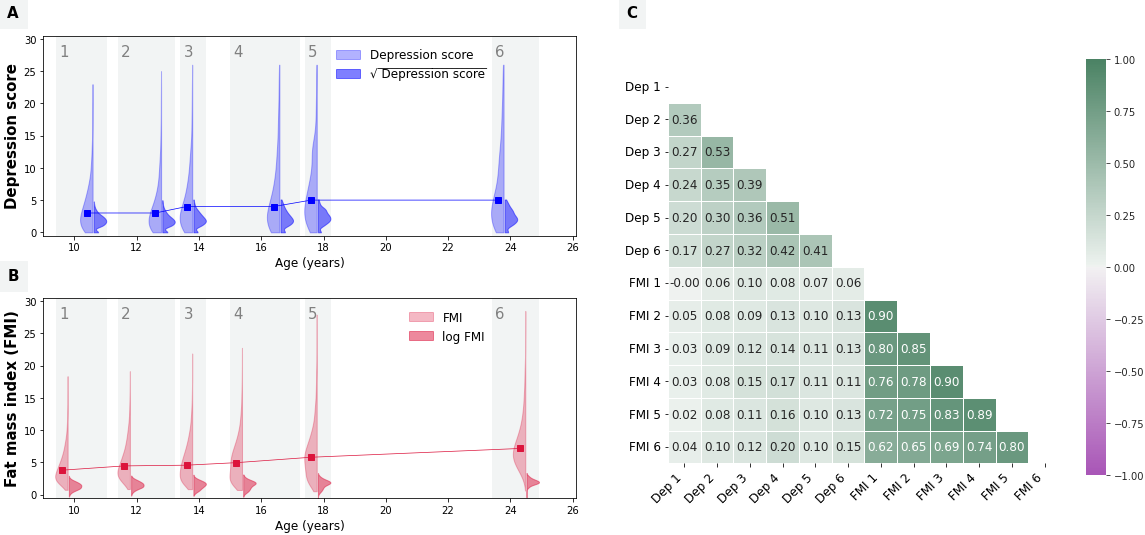

In [18]:
fig, axs = plt.subplot_mosaic('AC;.C;BC', figsize=(figwidth, 8.5),
                              width_ratios=[.52,.48], height_ratios=[.48,.15,.48], 
                              gridspec_kw=dict(hspace=0, wspace=0.18));

# age_dist(axs['a'], var='sDEP')
violin_plot(axs['A'], 'sDEP')
# boxplot(axs['A'], 'sDEP', 'Depression score',);

# axs['A'].plot([20,23],[25]*2, zonder=2)
axs['A'].text(19.71, 25.5, '______________________', va='bottom',ha='left', fontsize=fs_s-2)

# age_dist(axs['b'],var='FMI')
violin_plot(axs['B'], 'FMI')
# boxplot(axs['B'], 'FMI', 'Fat mass index (FMI)');

corrplot(axs['C']);

txtstyle = dict(fontsize=fs_m, fontweight='bold', bbox=dict(facecolor=cp_color, edgecolor=cp_color, pad=8))
fig.text(0.10, 0.91, 'A', **txtstyle);
fig.text(0.10, 0.48, 'B', **txtstyle);
fig.text(0.53, 0.91, 'C', **txtstyle);

fig.set_rasterized(True)

# fig.savefig('Figure1.png', bbox_inches='tight')

## eFIGURE 1

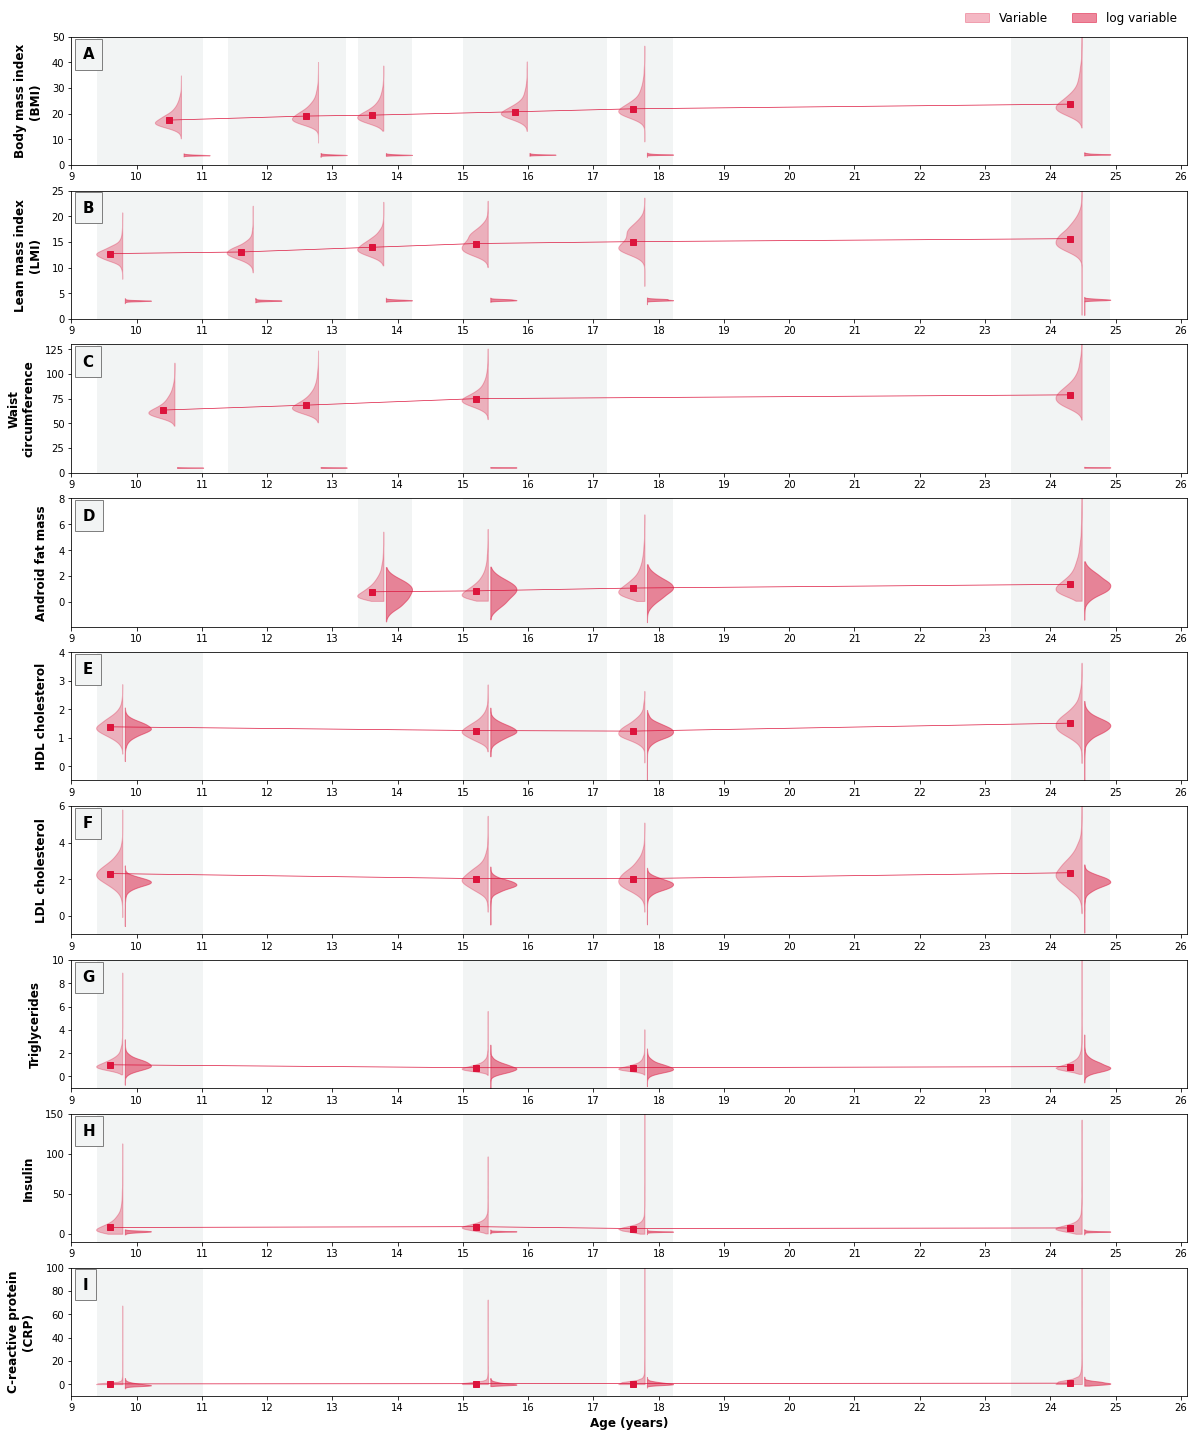

In [ ]:
def cmr_violin_plot(ax, cmr_var, cmr_name, ylims):

    # Model output
    fitm, esti, summ, cors = read_results('sDEP', cmr_var)

    # Times / number of observations
    td = [float(i.split('_')[-1][:-1]) for i in summ.columns[summ.columns.str.contains('sDEP')]]
    tf = [float(i.split('_')[-1][:-1]) for i in summ.columns[summ.columns.str.contains(cmr_var)]]
    n_obs = len(td)
    
    dset = data.loc[(data[summ.columns[summ.columns.str.contains(dep_var)]].T.isna().sum() < len(td)) &
                    (data[summ.columns[summ.columns.str.contains(cmr_var)]].T.isna().sum() < len(tf)), ]

    og_data = dset[summ.columns[summ.columns.str.contains(cmr_var)]]
     
    tr_data = og_data.transform(np.log) +1
    color = cmr_colors[0]
    times=tf
    
    def draw_half_violin(ax, d, pos='left'):
        # Remove NAs individually per column 
        d = [list(d.iloc[:,n].dropna()) for n in range(d.shape[1])]
    
        shift = -0.02 if pos=='left' else +0.02
        alpha = 0.3 if pos=='left' else 0.5
        
        v = ax.violinplot(d, points=100, positions=[t+shift for t in times], 
                          widths=.8, bw_method=0.3, showmeans=False, showextrema=False, showmedians=False)
        
        for b in v['bodies']:
            # get the center
            m = np.mean(b.get_paths()[0].vertices[:, 0])
            # modify the paths to not go further right than the center
            (clip1, clip2) = (-np.inf, m) if pos == 'left' else (m, np.inf)
            b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], clip1, clip2)
            b.set_color(color)
            b.set_alpha(alpha)
        
        return v['bodies'][0]
    
    p1 = draw_half_violin(ax, og_data, pos='left')
    p2 = draw_half_violin(ax, tr_data, pos='right')

    ax.plot([t-0.2 for t in times], og_data.median(), '-s', color=color, lw=0.7)
    
    # Legend 
    # labels = [cmr_var, f'log {cmr_var}']
    # ax.legend([p1, p2], labels, fontsize=fs_s, bbox_to_anchor=leg_pos, ncols=1, frameon=False)

    # Adjust axes
    ax.set(xlim=age_range, ylim=ylims)
    ylabel = cmr_name
    ax.set_ylabel(ylabel, fontsize=fs_s, fontweight='bold', labelpad=10)
    
    ax.set_xticks(np.arange(age_range[0], age_range[1], 1))
    ax.set_xticklabels([int(x) for x in np.arange(age_range[0], age_range[1], 1)], fontsize=fs_xs)

    # Add group "cross-sectional" time points using grey background
    crosspoints = [[9.4,11],[11.4,13.2],[13.4,14.2],[15,17.2],[17.4,18.2],[23.4,24.9]]

    
    [ax.axvspan(x1, x2, color=cp_color, zorder=0) for x1,x2 in crosspoints if any([x1<t<x2 for t in times]) ]
    # [ax.text(x1+0.1, 27.3, str(i+1), color='grey', fontsize=fs_m, zorder=1) for i, (x1,x2) in enumerate(crosspoints)]
    return p1, p2


# Dictionary of variables, labels and ranges
other_cmr = {'BMI': ['Body mass index\n(BMI)', [0, 50]],
             'LMI': ['Lean mass index\n(LMI)', [0, 25]],
             'waist_circ': ['Waist\ncircumference', [0, 130]],
             'android_fatmass': ['Android fat mass', [-1.9, 8]],
             'HDL_chol': ['HDL cholesterol', [-.5, 4]],
             'LDL_chol': ['LDL cholesterol', [-1, 6]],
             'triglyc': ['Triglycerides', [-1, 10]],
             'insulin': ['Insulin', [-10, 150]],
             'CRP': ['C-reactive protein\n(CRP)', [-10, 100]]}


import string
    
fig, axs = plt.subplot_mosaic('a;b;c;d;e;f;g;h;i', figsize=(figwidth, 25),)
                              #width_ratios=[.52,.48], height_ratios=[.12,.48,.15,.12,.48], 
                              #gridspec_kw=dict(hspace=0, wspace=0.18));


txtstyle = dict(fontsize=fs_m, fontweight='bold', bbox=dict(facecolor=cp_color, edgecolor='grey', pad=8))

# age_dist(axs['b'],var='FMI')
for n, v in enumerate(other_cmr.keys()):
    ax = string.ascii_lowercase[n]
    p1,p2 = cmr_violin_plot(axs[ax], v, other_cmr[v][0], other_cmr[v][1])
    axs[ax].text(0.01, 0.83, ax.upper(), transform=axs[ax].transAxes, **txtstyle)

axs['i'].set_xlabel('Age (years)', fontsize=fs_s, fontweight='bold')

fig.legend([p1, p2], ['Variable','log variable'], fontsize=fs_s, bbox_to_anchor=(0.9, 0.9), ncols=2, frameon=False)

fig.set_rasterized(True)

# fig.savefig('eFigure1.png', bbox_inches='tight')

## FIGURE 2

In [ ]:
def extract_est(est, name, n, esti=esti): 
    df = esti.loc[esti.label.str.contains(f'{est}_{name}{n}')]
    weight = float(df.est.iloc[0])
    label = f"{weight:.2f}\n[{df['ci.lower'].iloc[0]:.2f}; {df['ci.upper'].iloc[0]:.2f}]"
    label_fw = 'bold' if df['pvalue'].iloc[0]<0.050 else 'normal'
    estname = f'{est}_{name}'
    
    if est=='AR': 
        color = dep_colors[0] if name =='dep' else cmr_colors[0]
    else: 
        color = dep_colors[1] if name =='dep' else cmr_colors[1]
    
    return dict(weight=weight, label=label, label_fw=label_fw, color=color, name=estname)

def extract_corr(n, esti=esti): 
    df = esti.loc[esti.label.str.contains(f'cor{n}')]
    weight = float(df.est.iloc[0])
    label = f"{weight:.2f}\n[{df['ci.lower'].iloc[0]:.2f}; {df['ci.upper'].iloc[0]:.2f}]"
    label_fw = 'bold' if df['pvalue'].iloc[0]<0.050 else 'normal'
    
    return dict(weight=weight, label=label, label_fw=label_fw, color='grey')

def make_graph(ax, n_obs=6, names=['cmr','dep'], labs=['FMI','Dep']):
    
    G=nx.DiGraph()
    
    latent_node_style = dict(shape='o', color='white', size=1000)
    observ_node_style = dict(shape='s', color='none', size=1000)
    
    # Random intercepts
    G.add_node(f'ri_{names[1]}', pos =(n_obs/2+.5, 1), **latent_node_style)
    G.add_node(f'ri_{names[0]}', pos =(n_obs/2+.5, 0), **latent_node_style)
    G.add_edge(f'ri_{names[0]}',f'ri_{names[1]}', type='between_corr', name='between_corr', **extract_corr('vRI'))
    
    corr_text_style = dict(va='center', ha='center', fontsize=12, bbox=dict(facecolor='grey', edgecolor='none', pad=4, alpha=0.5))
    
    ax.text(n_obs+.85, 0.5, G.edges[(f'ri_{names[0]}',f'ri_{names[1]}')]['label'], 
            fontweight = G.edges[(f'ri_{names[0]}',f'ri_{names[1]}')]['label_fw'], **corr_text_style)
    
    pt, pb = 0.83, 0.17
    # Notes
    G.add_node('Depression\nscore', pos=(n_obs+1,pt), **observ_node_style)
    G.add_node('Fat mass\nindex (FMI)', pos=(n_obs+1,pb), **observ_node_style)
    
    for n in range(1,n_obs+1):
        # Observed variables
        G.add_node(f'{names[1]} {n}', pos=(n,pt), **observ_node_style)
        G.add_node(f'{names[0]} {n}', pos=(n,pb), **observ_node_style)

        text_style = dict(ha='center', fontsize=fs_l, fontweight='bold', bbox=dict(facecolor='w', edgecolor='k', pad=8))
        text_style_note = dict(ha='center', fontsize=fs_l-2, color='grey')
        ax.text(n, pt+.020, f'{labs[1]} {n}\n', va='top', **text_style)
        ax.text(n, pt-.025, f'{td[n-1]} y', va='top', **text_style_note)  
        ax.text(n, pb-.020, f'{labs[0]} {n}\n', va='bottom', **text_style)
        ax.text(n, pb-.025, f'{tf[n-1]} y', va='bottom', **text_style_note)  
        
        # Impulses
        G.add_node(f'u_{names[1]}{n}', pos=(n,pt-.13), **latent_node_style)
        G.add_node(f'u_{names[0]}{n}', pos=(n,pb+.13), **latent_node_style)
    
        # Loadings random intercepts
        G.add_edge(f'ri_{names[1]}', f'{names[1]} {n}', weight=1, type='loading', name='lambda')
        G.add_edge(f'ri_{names[0]}', f'{names[0]} {n}', weight=1, type='loading', name='lambda')
        # Loadings error terms (impulses)
        G.add_edge(f'u_{names[1]}{n}', f'{names[1]} {n}', weight=1, type='loading', name='error')
        G.add_edge(f'u_{names[0]}{n}', f'{names[0]} {n}', weight=1, type='loading', name='error')
        # Contemporaneous correlations
        G.add_edge(f'u_{names[0]}{n}',f'u_{names[1]}{n}', type='within_corr', name='within_corr', **extract_corr(f'r{n}'))
    
        ax.text(n-.16, 0.5, G.edges[(f'u_{names[0]}{n}',f'u_{names[1]}{n}')]['label'], # labels for correlations
                fontweight = G.edges[(f'u_{names[0]}{n}',f'u_{names[1]}{n}')]['label_fw'], **corr_text_style) 
    
        if n < 6:
            # Autoregressive terms
            G.add_edge(f'u_{names[1]}{n}', f'u_{names[1]}{n+1}', type='regress', **extract_est('AR', names[1], n))
            G.add_edge(f'u_{names[0]}{n}', f'u_{names[0]}{n+1}', type='regress', **extract_est('AR', names[0], n))
            # Cross-lag terms
            G.add_edge(f'u_{names[1]}{n}', f'u_{names[0]}{n+1}', type='regress', **extract_est('CL', names[0], n))
            G.add_edge(f'u_{names[0]}{n}', f'u_{names[1]}{n+1}', type='regress', **extract_est('CL', names[1], n))
    
    
    pos=nx.get_node_attributes(G, 'pos')
    
    for shape in set(['s','o']):
        # the nodes with the desired shapes
        node_list = [node for node in G.nodes() if G.nodes[node]['shape'] == shape]
        frame_color = 'black' if shape =='o' else 'none'
        nx.draw_networkx_nodes(G, pos,
                               nodelist = node_list,
                               node_size = [G.nodes[node]['size'] for node in node_list],
                               node_color= [G.nodes[node]['color'] for node in node_list],
                               edgecolors = frame_color,
                               node_shape = shape, ax=ax)

    def style_arrows(type):
        edge_list = [e for e in G.edges() if G.edges[e]['type'] == type]
        # width = [G.edges[edge]['weight'] for edge in edge_list] if type == 'regress' else 1
        width = 4 if type == 'regress' else 1
        color = [G.edges[edge]['color'] for edge in edge_list] if type == 'regress' else 'k'
        
        if type in ['loading','regress']:
            arrowstyle='->'
            connectionstyle = 'arc3,rad=0.0'  # straight line 
            # node_size = 1000 if type == 'loading' else 1000
            node_shape = 's'
            (min_source_margin, min_target_margin) = (0, 40) if type == 'loading' else (0,15)
        else:
            arrowstyle='<->'
            connectionstyle = 'arc3,rad=-.25'  if type == 'within_corr' else 'arc,angleA=2,angleB=-2,armA=550,armB=550,rad=250'
            # node_size=2000
            node_shape='o'
            min_source_margin, min_target_margin = 30, 30
        
        return dict(edgelist=edge_list, width=width, arrowstyle=arrowstyle, connectionstyle=connectionstyle, # node_size=node_size,
                    edge_color=color,
                    node_shape=node_shape, min_source_margin=min_source_margin, min_target_margin=min_target_margin)

    common_arrow_style = dict(arrows=True, arrowsize=20, ax=ax)
    
    for arrows in ['loading', 'regress', 'within_corr', 'between_corr']:
        nx.draw_networkx_edges(G, pos, **style_arrows(arrows), **common_arrow_style)
 
    def style_labels(estname):
        edge_list = [e for e in G.edges() if G.edges[e]['name'] == estname]
        edge_labels = [G.edges[edge]['label'] for edge in edge_list]

        color = [G.edges[edge]['color'] for edge in edge_list][0]

        lighter_color = lighter_colors[color]
    
        label_pos = 0.7 if estname.__contains__('CL') else 0.5
        
        return dict(edge_labels=dict(zip(edge_list, edge_labels)), 
                    label_pos=label_pos, font_size=fs_s, font_color='k', font_weight='bold', # font_family='Arial',
                    bbox=dict(facecolor=lighter_color, edgecolor='none', pad=4), # alpha=0.5
                    rotate=False)
    
    for label in ['AR_dep', 'AR_cmr', 'CL_dep', 'CL_cmr']:
         nx.draw_networkx_edge_labels(G, pos, **style_labels(label), ax=ax)

def resplot(ax, t1, t2, name, color, label, esti=esti, posx = 23.4):

    es = esti.loc[esti.label.str.contains(name)].reset_index()

    if name.__contains__('AR'):
        ms = ['s','s'] if name.__contains__('dep') else ['o','o']
        ylims = (-0.05,1.05)
        title = 'Persistence (autoregressive effects)'
    else: 
        ms = ['o','s'] if name.__contains__('dep') else ['s','o']
        ylims = (-0.015,0.265)
        title = 'Reciprocal influece (cross-lag effects)'

    for e in es.index:
        
        ls = '-' if es.loc[e, 'ci.lower'] > 0 else '--'

        ax.hlines(y=es.loc[e, 'est'], xmin=t1[e], xmax=t2[e+1], color=color, linewidth=2, linestyle=ls)

        for n,t in enumerate([t1[e],t2[e+1]]):
            ax.scatter(y=[es.loc[e, 'est']], x=[t], color=color, s=40, marker=ms[n], alpha=0.9)
            
        ax.fill_between([t1[e], t2[e+1]], es.loc[e, 'ci.lower'], es.loc[e, 'ci.upper'], color=color, alpha=.1)

    
    ax.set(xlim=age_range, ylim=ylims, xticks=np.arange(9,27))
    
    ax.axhline(y=0, linewidth=1, linestyle='--', color = 'grey')

    ax.set_ylabel('β estimate', fontsize=fs_m);
    ax.set_xlabel('Age (years)', fontsize=fs_m);

    # add legend
    space = (abs(ylims[0])+ylims[1])*.10
    posy = ylims[1] - space
    if 'dep' in name:
        posy = posy - space

    # Legend
    ax.hlines(y=posy, xmin=posx, xmax=posx+0.4, color=color, label=name,linewidth=2)
    ax.fill_between([posx, posx+0.4], posy+space/2.5, posy-space/2.5, color=color, alpha=.1)
    ax.text(posx+0.6, posy, label, color='k', fontsize=fs_m, va='center', fontweight='bold')
    # Title
    ax.text(0.5, 0.95, title, transform=ax.transAxes,
            color='k', fontsize=fs_l, ha='center', va='top', fontweight='bold')

    ax.grid(axis='both', linewidth=0.2, linestyle='-', color='grey') 

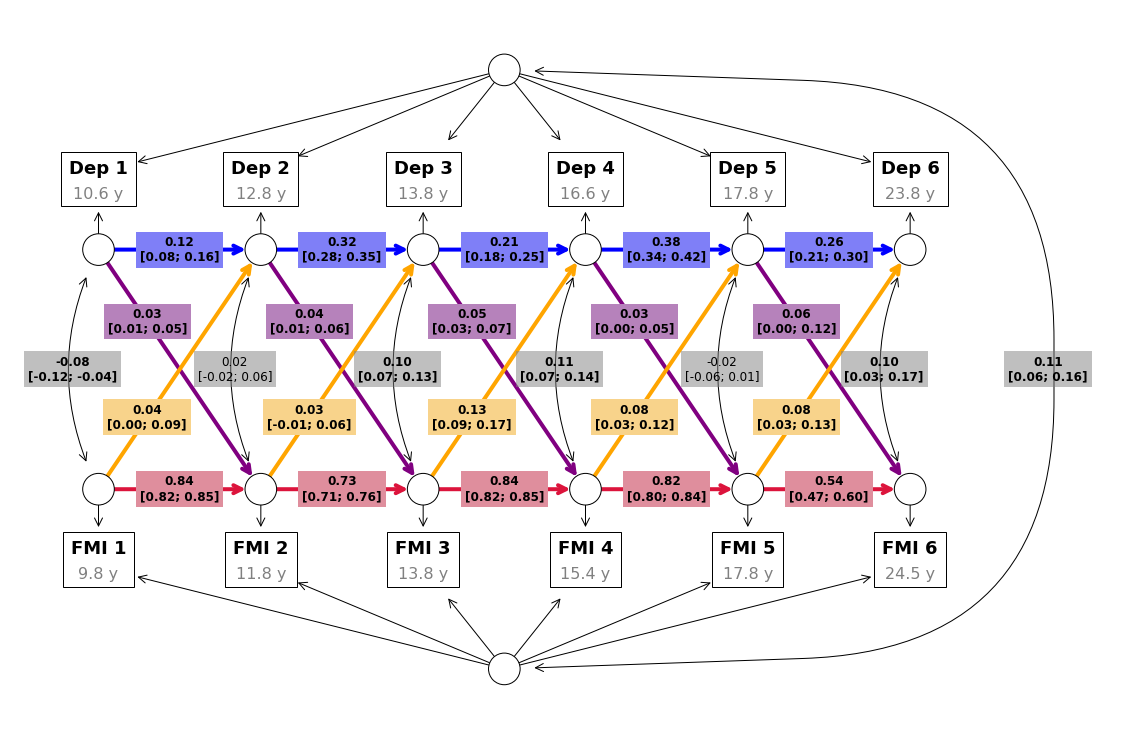

In [25]:
# fig, axs = plt.subplot_mosaic('A;b;B;.;C', figsize=(figwidth, 23),
#                               height_ratios=[1,.1,.3,.1,.3], gridspec_kw=dict(hspace=0))

fig, axs = plt.subplot_mosaic('A', figsize=(figwidth, figwidth/1.5)) 

make_graph(axs['A'])
axs['A'].axis('off')

# age_dist(axs['b'], var='sDEP')
# axb2 = axs['b'].twinx()
# age_dist(axb2, var='FMI')

# resplot(axs['B'], td,td,'AR_dep', color='blue', label = 'Depression')
# resplot(axs['B'], tf,tf,'AR_cmr', color='red', label = 'FMI')

# # age_violin(axs['c'],var='FMI')
# resplot(axs['C'], tf,td,'CL_dep', color='orange', label = 'FMI \u2192 Dep')
# resplot(axs['C'], td,tf,'CL_cmr', color='purple', label = 'Dep \u2192 FMI')

# txtstyle = dict(fontsize=fs_m, fontweight='bold', bbox=dict(facecolor=cp_color, edgecolor=cp_color, pad=8))
# fig.text(0.10, 0.855, 'A', **txtstyle);
# fig.text(0.10, 0.430, 'B', **txtstyle);
# fig.text(0.10, 0.255, 'C', **txtstyle);

fig.set_rasterized(True)

fig.savefig('Figure2.png', bbox_inches='tight')

## eFigure 2

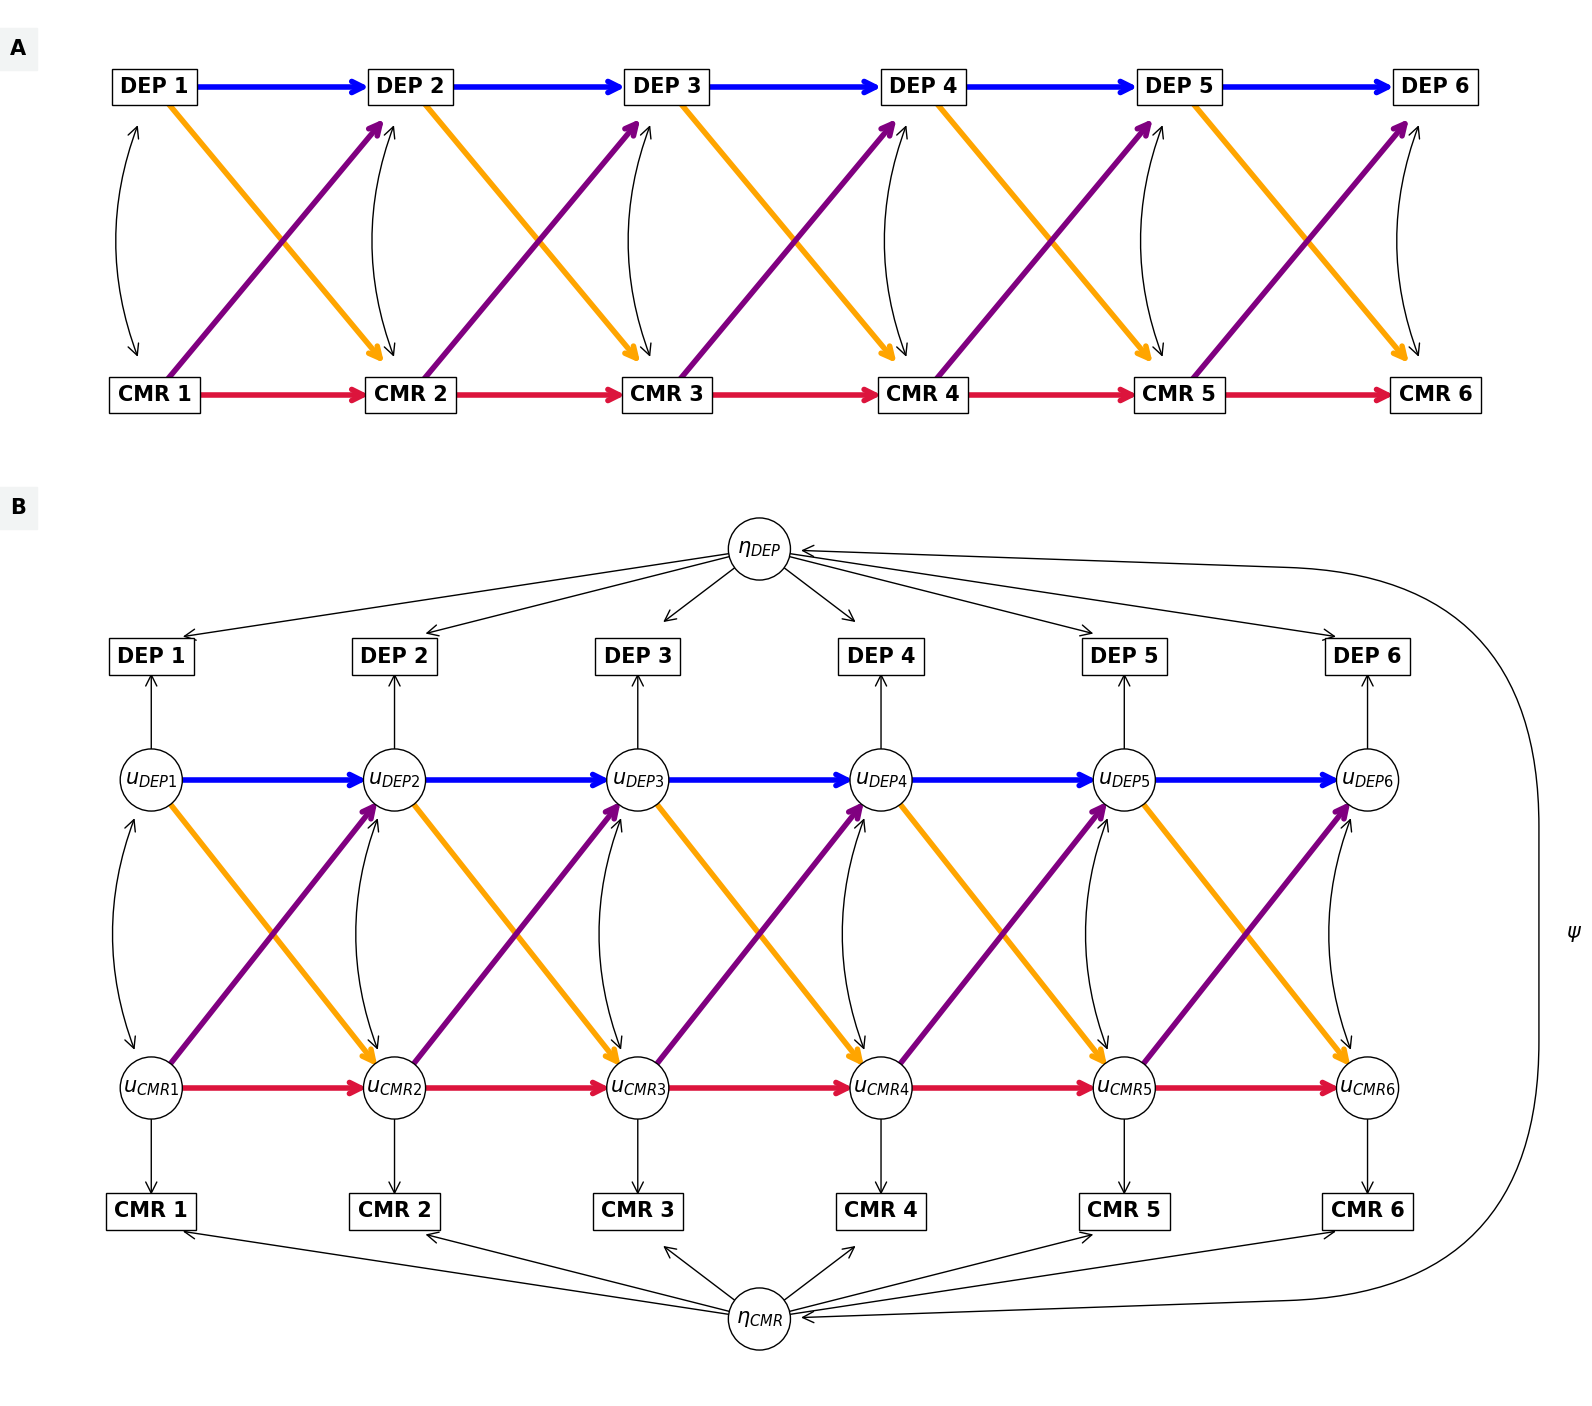

In [189]:
def make_graph_theory(ax, n_obs=6, names=['cmr','dep'], labs=['CMR','DEP'], model='ri'):
    
    G=nx.DiGraph()
    
    latent_node_style = dict(shape='o', color='w', size=2000)
    observ_node_style = dict(shape='s', color='none', size=2000)

    # Cannot make draw_networkx_labels() work so i will draw labels manually
    txt_style = dict(va='center', ha='center', fontsize=15, fontweight='bold', bbox=dict(facecolor='none', edgecolor='none', pad=4, alpha=0.5))
    txt_style2 = dict(va='center', ha='center', fontsize=15, fontweight='bold', bbox=dict(facecolor='w', edgecolor='black', pad=6, alpha=1))
    
    if model=='ri':
        # Random intercepts
        G.add_node(f'ri_{names[1]}', pos =(n_obs/2+.5, 1), **latent_node_style)
        G.add_node(f'ri_{names[0]}', pos =(n_obs/2+.5, 0), **latent_node_style)
        G.add_edge(f'ri_{names[0]}',f'ri_{names[1]}', type='between_corr', name='between_corr') #, **extract_corr('vRI'))

        ax.text(n_obs/2+.5, 1, r"$\eta_{DEP}$", **txt_style)
        ax.text(n_obs/2+.5, 0, r"$\eta_{CMR}$", **txt_style)
        ax.text(n_obs+.85, .5, r"$\psi$", **txt_style)
    
    pt, pb, dist = 0.88, 0.12, .18
    
    for n in range(1,n_obs+1):
        
        if model=='ri':
            # Observed variables
            G.add_node(f'{names[1]} {n}', pos=(n,pt), **observ_node_style)
            G.add_node(f'{names[0]} {n}', pos=(n,pb), **observ_node_style)
            
            ax.text(n, pt-.02, f'{labs[1]} {n}', **txt_style2)
            ax.text(n, pb+.02, f'{labs[0]} {n}', **txt_style2)
   
            # Impulses
            G.add_node(f'u_{names[1]}{n}', pos=(n,pt-dist), **latent_node_style)
            G.add_node(f'u_{names[0]}{n}', pos=(n,pb+dist), **latent_node_style)
    
            ax.text(n, pt-dist, r"$u_{%s %s}$" %(labs[1], str(n)), **txt_style)
            ax.text(n, pb+dist, r"$u_{%s %s}$" %(labs[0], str(n)), **txt_style)
        
            # Loadings random intercepts
            G.add_edge(f'ri_{names[1]}', f'{names[1]} {n}', weight=1, type='loading', name='lambda')
            G.add_edge(f'ri_{names[0]}', f'{names[0]} {n}', weight=1, type='loading', name='lambda')
            # Loadings error terms (impulses)
            G.add_edge(f'u_{names[1]}{n}', f'{names[1]} {n}', weight=1, type='loading', name='error')
            G.add_edge(f'u_{names[0]}{n}', f'{names[0]} {n}', weight=1, type='loading', name='error')
        else: 
            # Observed variables
            G.add_node(f'u_{names[1]}{n}', pos=(n,pt-dist), **observ_node_style)
            G.add_node(f'u_{names[0]}{n}', pos=(n,pb+dist), **observ_node_style)
            
            ax.text(n, pt-dist, f'{labs[1]} {n}', **txt_style2)
            ax.text(n, pb+dist, f'{labs[0]} {n}', **txt_style2)
            
        # Contemporaneous correlations
        G.add_edge(f'u_{names[0]}{n}',f'u_{names[1]}{n}', type='within_corr', name='within_corr') #, **extract_corr(f'r{n}'))
    
        if n < 6:
            # Autoregressive terms
            G.add_edge(f'u_{names[1]}{n}', f'u_{names[1]}{n+1}', type='regress', color=dep_colors[0]) # **extract_est('AR', names[1], n))
            G.add_edge(f'u_{names[0]}{n}', f'u_{names[0]}{n+1}', type='regress', color=cmr_colors[0]) # **extract_est('AR', names[0], n))
            # Cross-lag terms
            G.add_edge(f'u_{names[1]}{n}', f'u_{names[0]}{n+1}', type='regress', color=dep_colors[1]) # **extract_est('CL', names[0], n))
            G.add_edge(f'u_{names[0]}{n}', f'u_{names[1]}{n+1}', type='regress', color=cmr_colors[1]) # **extract_est('CL', names[1], n))

    
    pos=nx.get_node_attributes(G, 'pos')
    
    for shape in set(['s','o']):
        # the nodes with the desired shapes
        node_list = [node for node in G.nodes() if G.nodes[node]['shape'] == shape]
        frame_color = 'black' if shape =='o' else 'none'
        nx.draw_networkx_nodes(G, pos,
                               nodelist = node_list,
                               node_size = [G.nodes[node]['size'] for node in node_list],
                               node_color= [G.nodes[node]['color'] for node in node_list],
                               edgecolors = frame_color,
                               node_shape = shape, ax=ax)

    
    def style_arrows(type):
        edge_list = [e for e in G.edges() if G.edges[e]['type'] == type]
        # width = [G.edges[edge]['weight'] for edge in edge_list] if type == 'regress' else 1
        width = 4 if type == 'regress' else 1
        color = [G.edges[edge]['color'] for edge in edge_list] if type == 'regress' else 'k'
        
        if type in ['loading','regress']:
            arrowstyle='->'
            connectionstyle = 'arc3,rad=0.0'  # straight line 
            # node_size = 1000 if type == 'loading' else 1000
            node_shape = 's'
            (min_source_margin, min_target_margin) = (0, 23) if type == 'loading' else (0,20) if model =='ri' else (0,30)
            
        else:
            arrowstyle='<->'
            connectionstyle = 'arc3,rad=-.25'  if type == 'within_corr' else 'arc,angleA=2,angleB=-2,armA=780,armB=780,rad=250'
            # node_size=2000
            node_shape='o'
            min_source_margin, min_target_margin = 30, 30
        
        return dict(edgelist=edge_list, width=width, arrowstyle=arrowstyle, connectionstyle=connectionstyle, # node_size=node_size,
                    edge_color=color,
                    node_shape=node_shape, min_source_margin=min_source_margin, min_target_margin=min_target_margin)

    common_arrow_style = dict(arrows=True, arrowsize=20, ax=ax)
    
    for arrows in ['loading', 'regress', 'within_corr', 'between_corr']:
        nx.draw_networkx_edges(G, pos, **style_arrows(arrows), **common_arrow_style)

    ax.set_ylim(-.1,1.1) if model =='ri' else ax.set_ylim(.2,.8)
    ax.axis('off')


fig, axs = plt.subplot_mosaic('A;B', figsize=(figwidth, 18),  height_ratios=[.6,1.2], gridspec_kw=dict(hspace=0))

make_graph_theory(axs['A'], model='clpm')
make_graph_theory(axs['B'])

txtstyle = dict(fontsize=fs_m, fontweight='bold', bbox=dict(facecolor=cp_color, edgecolor=cp_color, pad=8))
fig.text(0.12, 0.855, 'A', **txtstyle);
fig.text(0.12, 0.600, 'B', **txtstyle);


fig.set_rasterized(True)

fig.savefig('eFigure2.png', bbox_inches='tight')

In [31]:
other_cmr_names = {'FMI': 'Fat mass index (FMI)',
                   'BMI': 'Body mass index (BMI)',
                   'LMI': 'Lean mass index (LMI)',
                   'waist_circ': 'Waist circumference',
                   'android_fatmass': 'Android fat mass',
                   'HDL_chol': 'HDL cholesterol',
                   'LDL_chol': 'LDL cholesterol', 
                   'triglyc': 'Triglycerides',
                   'insulin': 'Insulin', 
                   'CRP': 'C-reactive protein (CRP)'}


## FIGURE 3

/var/folders/f9/fknlq25n23l74zmhg8zbckx80000gn/T/ipykernel_38161/3665845457.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out_table = pd.concat(out_list)
/var/folders/f9/fknlq25n23l74zmhg8zbckx80000gn/T/ipykernel_38161/3665845457.py:50: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(labels)


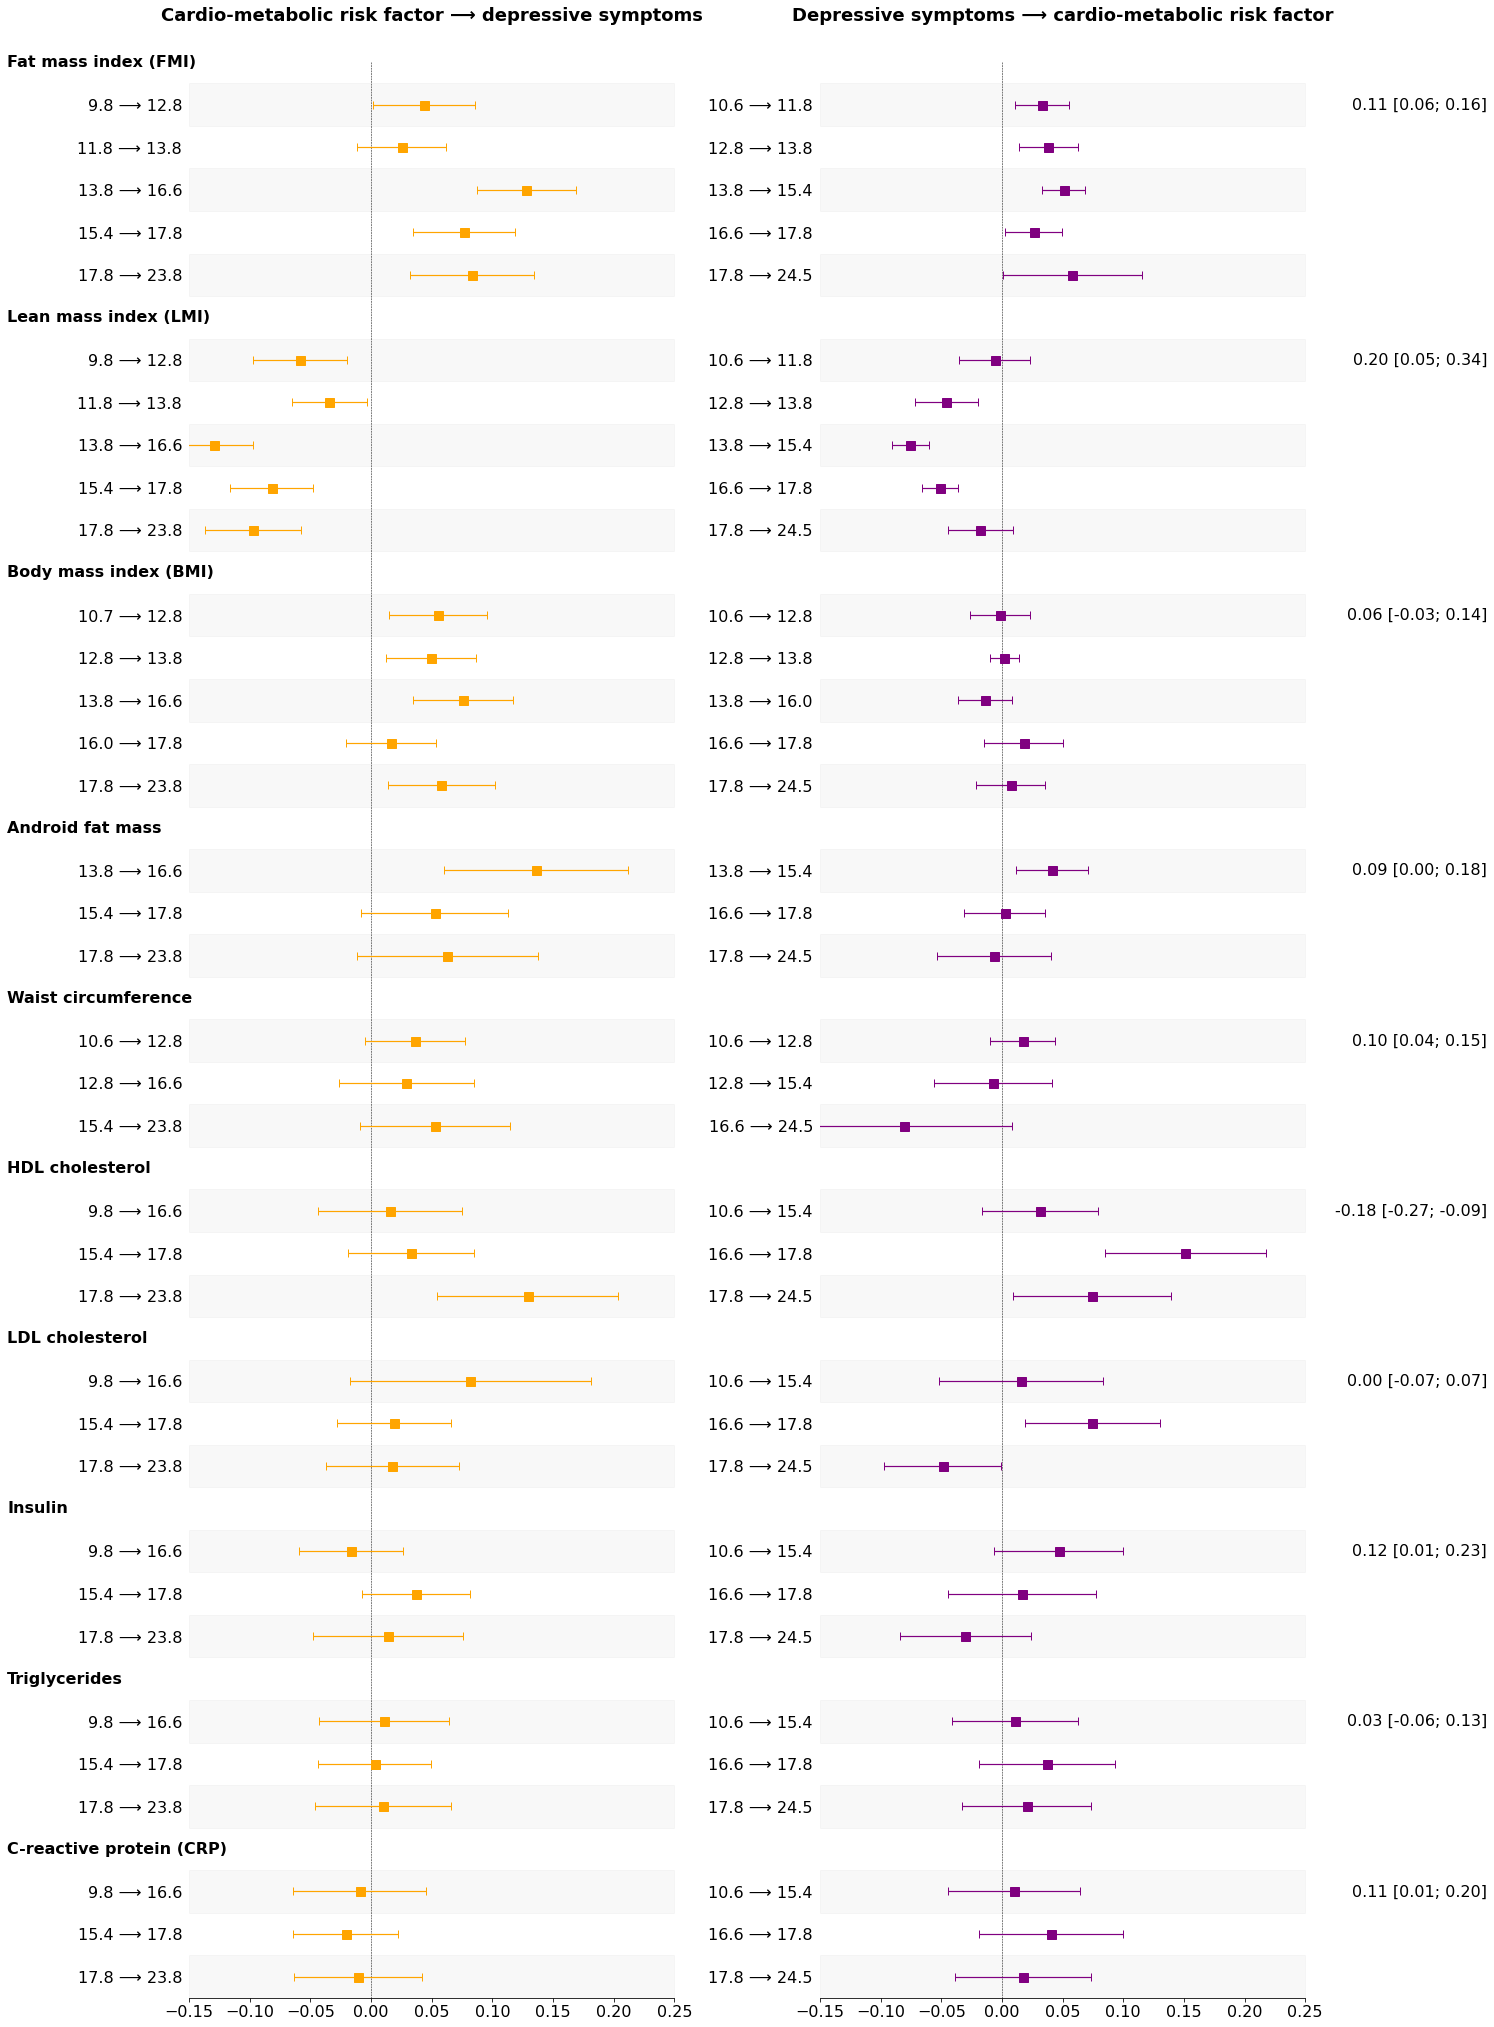

In [72]:
stxt1, stxt2, stxt3 = 16, 16, 18

out_list = []

for cmr in ['FMI','LMI','BMI','android_fatmass','waist_circ','HDL_chol','LDL_chol','insulin','triglyc','CRP']:
    for term in ['CL_dep','CL_cmr','cov']:
        d = get_results(name=term, dep='sDEP', cmr=cmr, model='riclpm')
        blank = pd.DataFrame({'cmr': [cmr], 'term': ['cmr_or_dep'], 'est2': [None], 'age': [''], 'time': [None], 'yest': [None], 'P': [None],
                              'est': [None], 'ci.lower': [None], 'ci.lower': [None]})
        out_list.extend([blank, d])
    
# see pd.concat documentation for more info
out_table = pd.concat(out_list)

def CL_forest(ax, direction, color, title, ylim0=-0.5, xlims=[-.15,.25], group_sizes = [6]*3+[4]*7, add_group_labels=True):

    ylim1 = np.sum(group_sizes) + ylim0
    
    # Subset results 
    res = out_table.loc[out_table.term.str.contains(direction), ]
    # Draw forest 
    ax.errorbar(x=res['est'], y=res['cmr']+'/'+res['age'],
                xerr=[res['est'] - res['ci.lower'], res['ci.upper'] - res['est']],
                color=color, # ['grey' if p>.05 else color for p in res['P']],
                ecolor=color, fmt='s', ms=9,
                elinewidth=1.2,
                capsize=4,
                ls='none',
                zorder=3)
    
    # Draw reference line
    _offset = 0.5
    ax.vlines(x=0, ymin=ylim0+_offset, ymax=ylim1+_offset, linestyles='--', color='k', linewidth=0.5)
    
    # Adjust axes 
    ax.set_xlim(xlims)
    ax.set_ylim(ylim0,ylim1)
    ax.invert_yaxis()
    ax.spines[['top','left','right']].set_color('None')
    ax.tick_params(top=False,
                   bottom=True,
                   left=False,
                   right=False,
                   labelleft=True,
                   labelright=False,
                   labelbottom=True)

    # Labels
    labels = [(' ').join(item.get_text().split('/')[1:]) for item in ax.get_yticklabels() ]
    ax.set_yticklabels(labels)
    ax.tick_params(axis='both', labelsize=stxt1)

    # Title
    ax.set_title(title, fontsize=stxt3, fontweight='bold', pad=20)

    for i in range(int(ylim1)): 
        if (i % 2) == 0:
            ax.fill_between(xlims, i+0.5, i+1.5, color='silver', alpha=.1)

    positions = [0] + list(np.cumsum(group_sizes))
    
    # Format group labels 
    for i, grp in enumerate(res['cmr'].unique()):
        if add_group_labels:
            grp_name = other_cmr_names[grp]
            ax.text(-.30, positions[i], grp_name, fontsize=stxt2, fontweight='bold', va='center', ha='left')
        else: 
            cov = out_table.loc[out_table.term.str.contains('cov'), ]
            ax.text(.40, positions[i]+1, cov.iloc[i,2], fontsize=stxt2, va='center', ha='right')

fig, axs = plt.subplot_mosaic('AB', figsize=(figwidth, figwidth*1.8), gridspec_kw=dict(wspace=0.3))# , width_ratios=[1.1,1.1,.1], );

CL_forest(axs['A'], 'dep', 'orange', 'Cardio-metabolic risk factor ⟶ depressive symptoms')
CL_forest(axs['B'], 'cmr', 'purple', 'Depressive symptoms ⟶ cardio-metabolic risk factor', add_group_labels=False)

fig.set_rasterized(True)

# fig.savefig('Figure3.png', bbox_inches='tight')

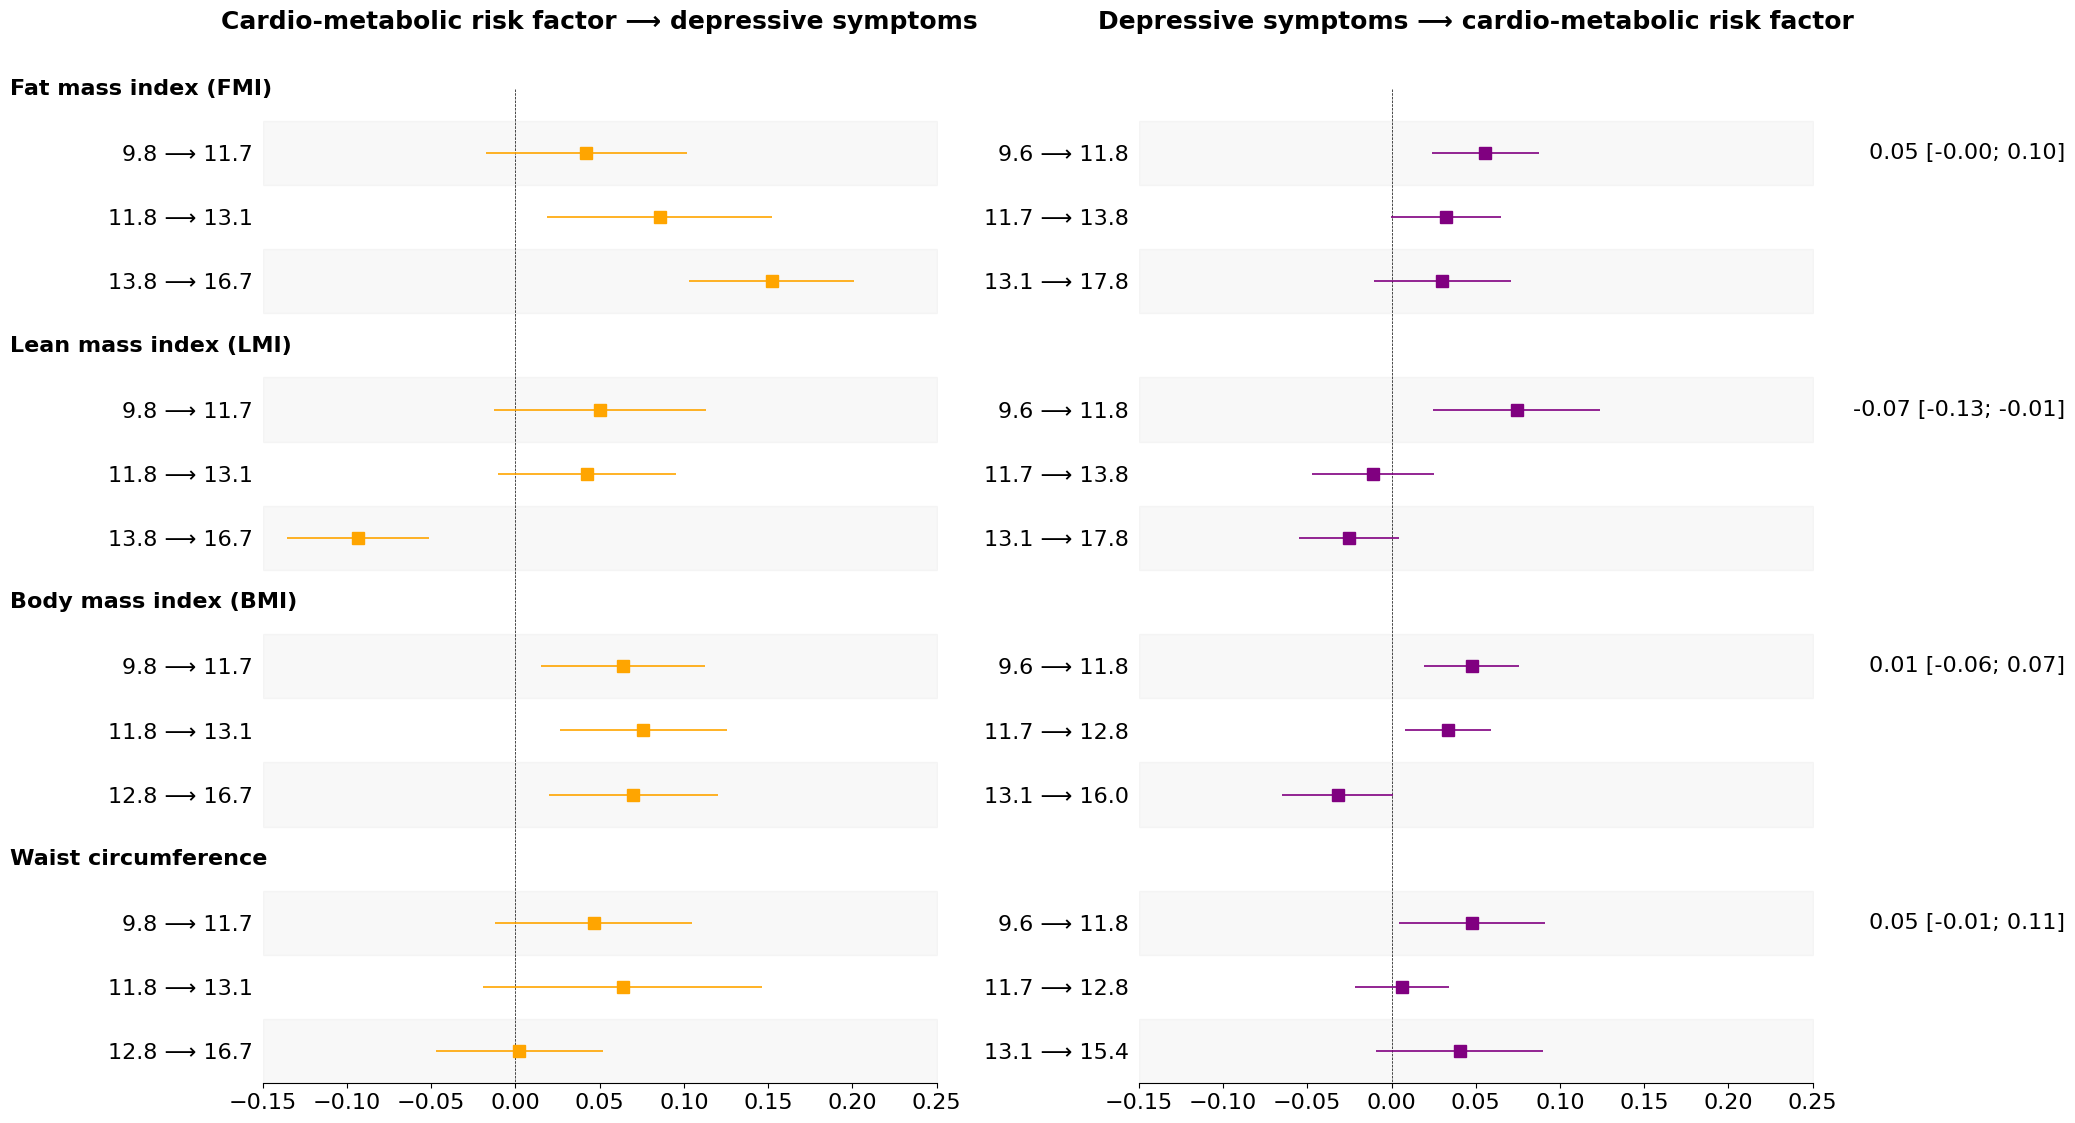

In [346]:
out_list = []

for cmr in ['FMI','LMI','BMI','waist_circ']:
    for term in ['CL_dep','CL_cmr','cov']:
        d = get_results(name=term, dep='mDEP', cmr=cmr)
        blank = pd.DataFrame({'cmr': [cmr], 'term': ['cmr_or_dep'], 'est2': [None], 'age': [''], 'time': [None], 'yest': [None], 'P': [None],
                              'est': [None], 'ci.lower': [None], 'ci.lower': [None]})
        out_list.extend([blank, d])
    
# see pd.concat documentation for more info
out_table = pd.concat(out_list)


fig, axs = plt.subplot_mosaic('AB', figsize=(figwidth, figwidth/1.5), gridspec_kw=dict(wspace=0.3))# , width_ratios=[1.1,1.1,.1], );

CL_forest(axs['A'], 'dep', 'orange', 'Cardio-metabolic risk factor ⟶ depressive symptoms', group_sizes=[4]*4)
CL_forest(axs['B'], 'cmr', 'purple', 'Depressive symptoms ⟶ cardio-metabolic risk factor', group_sizes=[4]*4, add_group_labels=False)

fig.set_rasterized(True)

fig.savefig('eFigure3.png', bbox_inches='tight')

# OTHER (revision 1)

Display ALT-SR model only where it converged and performed significantly better than RI-CLPM 

/var/folders/f9/fknlq25n23l74zmhg8zbckx80000gn/T/ipykernel_38161/3499156780.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out_table = pd.concat(out_list)
/var/folders/f9/fknlq25n23l74zmhg8zbckx80000gn/T/ipykernel_38161/3499156780.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  alt_table = pd.concat(alt_list)
/var/folders/f9/fknlq25n23l74zmhg8zbckx80000gn/T/ipykernel_38161/3499156780.py:70: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels

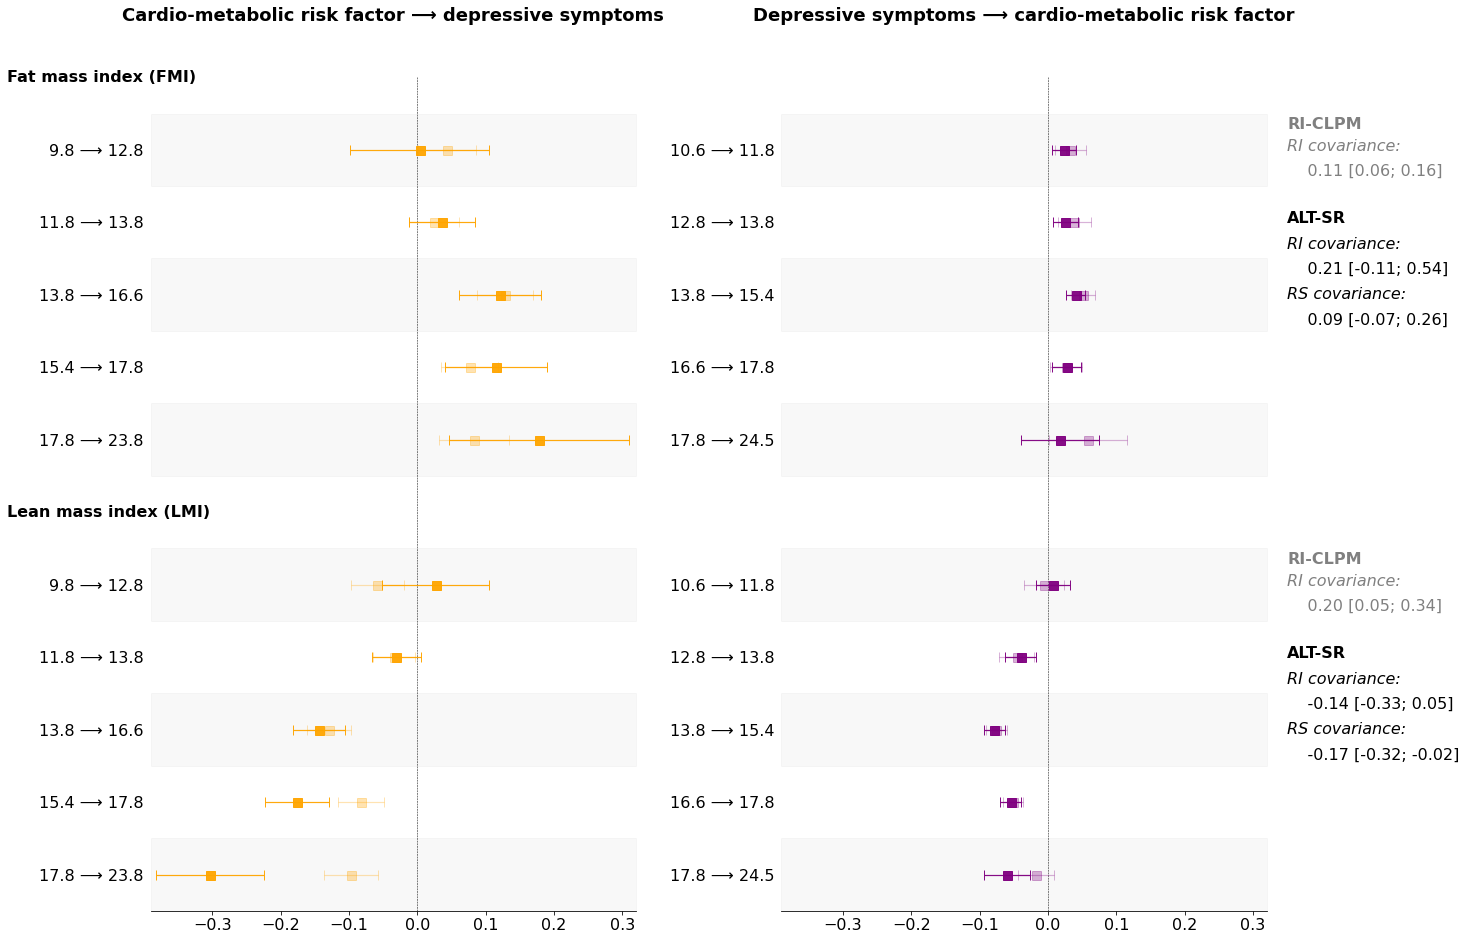

In [125]:
stxt1, stxt2, stxt3 = 16, 16, 18


out_list = []
alt_list = []

for cmr in ['FMI','LMI']:
    for term in ['CL_dep','CL_cmr','cov']:
        d = get_results(name=term, dep='sDEP', cmr=cmr, model='riclpm')
        d_alt = get_results(name=term, dep='sDEP', cmr=cmr, model='altsr')

        blank = pd.DataFrame({'cmr': [cmr], 'term': ['cmr_or_dep'], 'est2': [None], 
                              'age': [''], 'time': [None], 'yest': [None], 'P': [None],
                              'est': [None], 'ci.lower': [None], 'ci.lower': [None]})
        
        out_list.extend([blank, d])
        alt_list.extend([blank, d_alt])
    
# see pd.concat documentation for more info
out_table = pd.concat(out_list)
alt_table = pd.concat(alt_list)

def CL_forest(ax, direction, color, title, ylim0=-0.5, xlims=[-.39,.32], 
              group_sizes = [6]*2+[4]*0, add_group_labels=True):

    ylim1 = np.sum(group_sizes) + ylim0
    
    # Subset results 
    res = out_table.loc[out_table.term.str.contains(f'CL_{direction}|or'), ]
    alt_res = alt_table.loc[alt_table.term.str.contains(f'CL_{direction}|or'), ]
    # Draw forest for RI-CLPM
    ax.errorbar(x=res['est'], y=res['cmr']+'/'+res['age'],
                xerr=[res['est'] - res['ci.lower'], res['ci.upper'] - res['est']],
                color=color, # ['grey' if p>.05 else color for p in res['P']],
                ecolor=color, fmt='s', ms=9,
                elinewidth=1.2,
                capsize=5,
                ls='none',
                zorder=5, alpha=0.3)
    
    # Draw forest for alternative model (ALT-SR)
    ax.errorbar(x=alt_res['est'], y=alt_res['cmr']+'/'+alt_res['age'],
                xerr=[alt_res['est'] - alt_res['ci.lower'], alt_res['ci.upper'] - alt_res['est']],
                color=color, # ['grey' if p>.05 else color for p in res['P']],
                ecolor=color, fmt='s', ms=9,
                elinewidth=1.2,
                capsize=5,
                ls='none',
                zorder=4, alpha=0.95)
    
    # Draw reference line
    _offset = 0.5
    ax.vlines(x=0, ymin=ylim0+_offset, ymax=ylim1+_offset, linestyles='--', color='k', linewidth=0.5)
    
    # Adjust axes 
    ax.set_xlim(xlims)
    ax.set_ylim(ylim0, ylim1)
    ax.invert_yaxis()
    ax.spines[['top','left','right']].set_color('None')
    ax.tick_params(top=False,
                   bottom=True,
                   left=False,
                   right=False,
                   labelleft=True,
                   labelright=False,
                   labelbottom=True)

    # Labels
    labels = [(' ').join(item.get_text().split('/')[1:]) for item in ax.get_yticklabels() ]
    ax.set_yticklabels(labels)
    ax.tick_params(axis='both', labelsize=stxt1)

    # Title
    ax.set_title(title, fontsize=stxt3, fontweight='bold', pad=20)

    # Draw shaded background
    for i in range(int(ylim1)): 
        if (i % 2) == 0:
            ax.fill_between(xlims, i+0.5, i+1.5, color='silver', alpha=.1)

    positions = [0] + list(np.cumsum(group_sizes))
    
    # Format group labels 
    for i, grp in enumerate(res['cmr'].unique()):
        if add_group_labels:
            grp_name = other_cmr_names[grp]
            ax.text(-.60, positions[i], grp_name, fontsize=stxt2, fontweight='bold', va='center', ha='left')
        else: 
            txtstyle = dict(x=.35, fontsize=stxt2, va='center', ha='left')
            # Instectept correlation in the RI-CLPM
            cov = out_table.loc[out_table.term.str.contains('cov'), ]
            ax.text(y=positions[i]+0.65, s='RI-CLPM', color='grey', **txtstyle, fontweight='bold')
            ax.text(y=positions[i]+0.95, s='RI covariance:', color='grey', **txtstyle, fontstyle='italic')
            ax.text(y=positions[i]+1.30, s=f'    {cov.iloc[i,2]}', color='grey', **txtstyle)

            # Intercept and slopes correlation in the ALT-SR
            cov_alt_ri = alt_table.loc[alt_table.term == 'covRI', ]
            cov_alt_rs = alt_table.loc[alt_table.term == 'covRS', ]
            ax.text(y=positions[i]+1.95, s='ALT-SR', color='black', **txtstyle, fontweight='bold')
            ax.text(y=positions[i]+2.30, s='RI covariance:', color='black', **txtstyle, fontstyle='italic')
            ax.text(y=positions[i]+2.65, s=f'    {cov_alt_ri.iloc[i,2]}', color='black', **txtstyle)

            ax.text(y=positions[i]+3.00, s='RS covariance:', color='black', **txtstyle, fontstyle='italic')
            ax.text(y=positions[i]+3.35, s=f'    {cov_alt_rs.iloc[i,2]}', color='black', **txtstyle)


fig, axs = plt.subplot_mosaic('AB', figsize=(figwidth, figwidth*.8), gridspec_kw=dict(wspace=0.3))# , width_ratios=[1.1,1.1,.1], );

CL_forest(axs['A'], 'dep', 'orange', 'Cardio-metabolic risk factor ⟶ depressive symptoms')
CL_forest(axs['B'], 'cmr', 'purple', 'Depressive symptoms ⟶ cardio-metabolic risk factor', add_group_labels=False)

fig.set_rasterized(True)

fig.savefig('eFigure4.png', bbox_inches='tight')